# Module 08 Lab - The Bias-Variance Tradeoff

**Objective:** To understand and visualize the concepts of **overfitting**, **underfitting**, and the **bias-variance tradeoff**, which are central to building models that generalize well to new data.

**In this lab, you will train models of varying complexity and plot their performance to see these concepts in action.**

## Part 1: Understanding the Concepts

*   **Underfitting (High Bias):** The model is **too simple** and fails to capture the underlying patterns in the data. It performs poorly on both the training data and the test data. It has high bias because it makes strong, incorrect assumptions about the data.

*   **Overfitting (High Variance):** The model is **too complex** and learns the training data too well, including the noise and random fluctuations. It performs exceptionally well on the training data but poorly on the test data because it has memorized the training set instead of learning the general pattern. It has high variance because its performance changes drastically with different training data.

*   **The Goal:** Find a model that is "just right"—complex enough to capture the true pattern but not so complex that it memorizes the noise. This is the **bias-variance tradeoff**.

## Part 2: Setup

To visualize this, we will create a synthetic (fake) dataset with a known pattern and some noise.

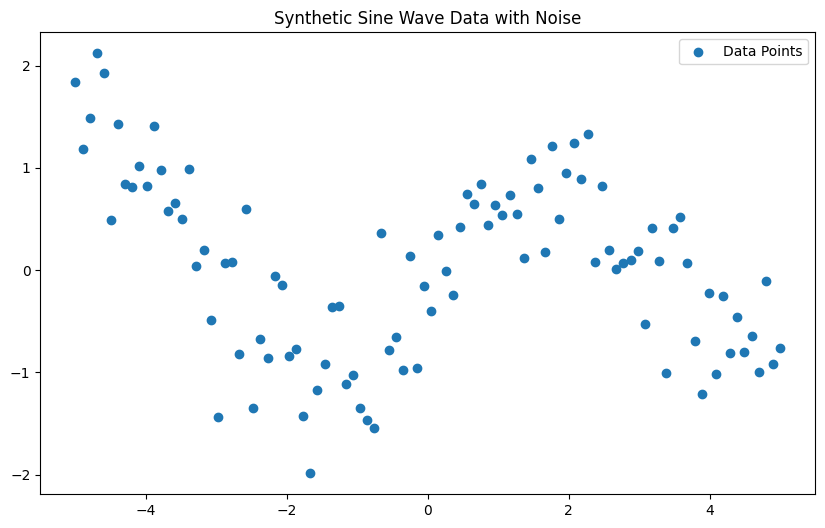

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

# Generate some synthetic data
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = np.sin(X) + np.random.normal(0, 0.5, 100)
X = X[:, np.newaxis]

# Plot the data to see the underlying sine wave pattern
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Data Points')
plt.title('Synthetic Sine Wave Data with Noise')
plt.legend()
plt.show()

## Part 3: Modeling with Different Complexities

We will use **Polynomial Regression** to control model complexity. A polynomial of degree 1 is a simple straight line (underfitting). A polynomial of degree 15 is a very complex, wiggly line (overfitting).

**Your Task:** Train and visualize three models with different degrees (1, 4, and 15) to see underfitting, a good fit, and overfitting.

### Task 1: Train and Plot Models

**Your Task:** For each degree (1, 4, 15), create a polynomial regression model, train it, and plot its predictions against the original data.

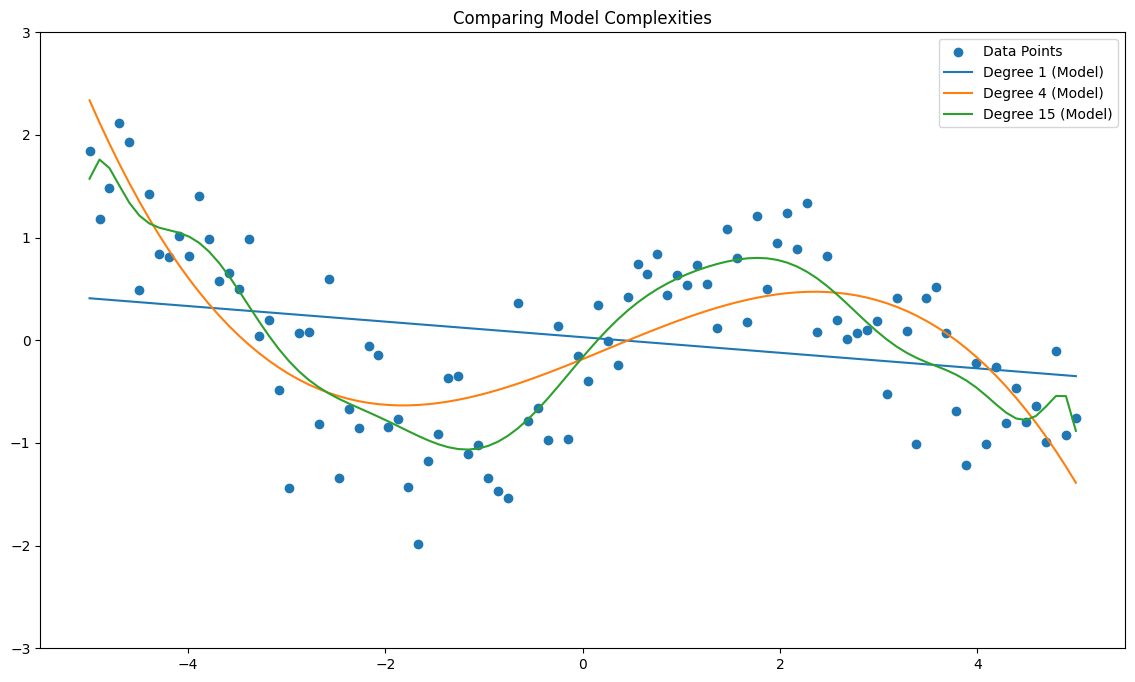

In [ ]:
# --- ENTER YOUR CODE HERE ---
# Train and compare polynomial regression models of different complexity

plt.figure(figsize=(14, 8))
plt.scatter(X, y, label='Data Points')

degrees = [1, 4, 15]
for degree in degrees:
    # 1. Create a pipeline that adds polynomial features and then fits a linear regression model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

    # 2. Train the model
    model.fit(X, y)

    # 3. Make predictions
    y_pred = model.predict(X)

    # 4. Plot the model's predictions
    plt.plot(X, y_pred, label=f'Degree {degree} (Model)')

plt.legend()
plt.title('Comparing Model Complexities')
plt.ylim(-3, 3)
plt.show()

## Part 4: Learning Curves

**Concept:** A **learning curve** is a powerful tool to diagnose bias and variance. It plots the model's performance (e.g., accuracy or error) on both the **training set** and the **validation set** as a function of the number of training samples.

*   **High Bias (Underfitting):** Both the training score and validation score will be low and will plateau quickly. The model is too simple to learn from more data.
*   **High Variance (Overfitting):** There will be a large gap between the high training score and the low validation score. The model memorized the training data but can't generalize.
*   **Just Right:** The training and validation scores will converge to a high value.

### Task 2: Plot Learning Curves

**Your Task:** Use the `learning_curve` function from scikit-learn to plot the learning curves for the underfit (degree 1) and overfit (degree 15) models.

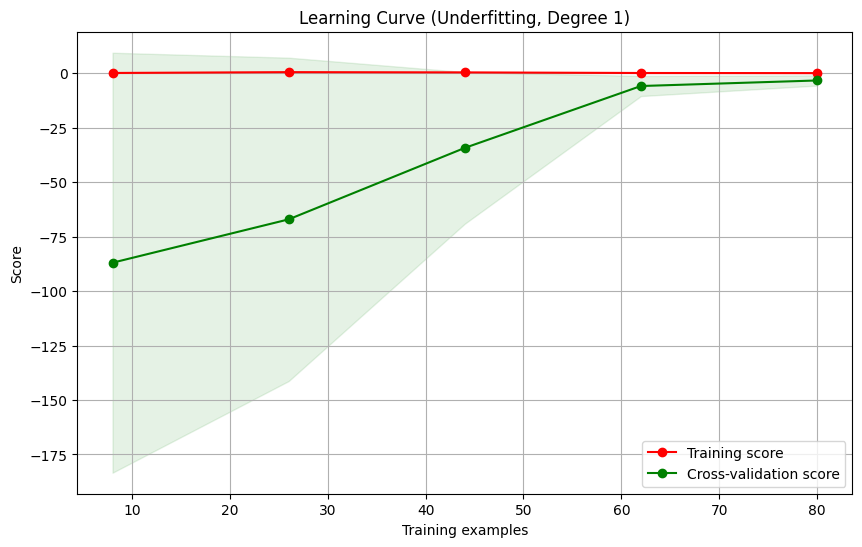

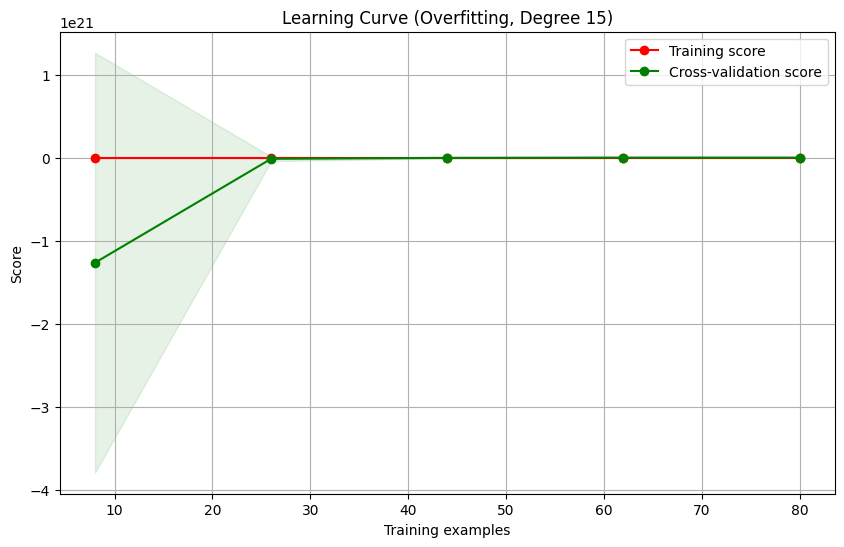

In [ ]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

# --- ENTER YOUR CODE HERE ---

# 1. Create the underfit and overfit models
# Underfitting model: degree 1
# Overfitting model: degree 15
underfit_model = make_pipeline(PolynomialFeatures(1), LinearRegression())
overfit_model = make_pipeline(PolynomialFeatures(15), LinearRegression())

# 2. Plot the learning curve for the underfit model
plot_learning_curve(underfit_model, "Learning Curve (Underfitting, Degree 1)", X, y, cv=5)
plt.show()

# 3. Plot the learning curve for the overfit model
plot_learning_curve(overfit_model, "Learning Curve (Overfitting, Degree 15)", X, y, cv=5)
plt.show()

## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.

### **1. In the first plot of the three models, which model (degree 1, 4, or 15) is underfitting, which is overfitting, and which is a good fit? Explain your reasoning.**

**[Huong Nguyen]:**

The classification is directly supported by how each curve aligns with the data distribution:

- **Degree 1 → Underfitting**
The prediction line remains nearly linear while the data clearly follows a nonlinear pattern. The model systematically deviates from the data across the entire range, not just locally. This consistent error indicates **high bias**, where the model is too simple to represent the underlying function.

- **Degree 4 → Good Fit**
The curve follows the overall shape of the data and captures the main trend without reacting to small fluctuations. There are no sharp oscillations or extreme bends. This indicates the model is capturing signal rather than noise, representing an effective **bias-variance balance**.

- **Degree 15 → Overfitting**
The curve shows rapid oscillations and bends sharply between nearby points. It aligns very closely with individual data points, including noise, especially near the boundaries. This behavior indicates **high variance**, where the model is overly sensitive to training data.

**[Alissa]:**

The three models represent different levels of complexity, which directly affect their ability to capture the underlying pattern of the data. By comparing how each model behaves relative to the data distribution, it is possible to identify cases of underfitting, overfitting, and an appropriate balance between bias and variance.

**Degree 1 → Underfitting (High Bias):**  This model fails to represent the structure of the data because it assumes a simple linear relationship. Since the actual pattern is nonlinear, the model cannot adapt, leading to systematic errors across all regions of the dataset. This indicates high bias, as the model is too constrained to learn the true relationship.

**Degree 4 → Good Fit (Balanced Bias & Variance):** This model provides a representation that is flexible enough to capture the underlying pattern without becoming overly sensitive to minor fluctuations. It reflects the general trend of the data while maintaining smoothness, which suggests good generalization performance on unseen data.

**Degree 15 → Overfitting (High Variance):** This model introduces excessive flexibility, allowing it to adapt to noise rather than just the underlying pattern. Instead of learning the true relationship, it memorizes variations in the training data, resulting in a model that is unstable and likely to perform poorly on new data.

This comparison shows that model performance is not only about fitting the data well, but about finding the right level of complexity to generalize effectively.

**[Stuart]:** 

Degree 1 is underfitting as the cross-validation score doesn't follow a line with the training score. As the model doesn't take enough variance into account, it doesn't track the data curve properly and ends up with a straight line following the slope of the data but not the curve. There is high bias in the model.

Degree 4 is a good fit where the cross validation follows the trend of the training data but doesn't oscillate too much when local maxima and minima are introduced, it maintains the overall curve. This shows a balance between bias and variance.

Degree 15 shows overfitting where the model has begun to try and match each data point rather than the data trend. Oscillations have emerged instead of a smooth curve. There is high variance in the model and low bias. 

**[Ruben]: [ENTER YOUR ANSWERS HERE]**

### **2.  Looking at the learning curve for the underfitting model, what do you observe about the training and cross-validation scores? What does this tell you?**

**[Huong Nguyen]**

The learning curve shows:
- **Training score is low and plateaus early**
- **Cross-validation score is also low and closely tracks the training score**
- **Minimal gap between the two curves across all training sizes**

This pattern indicates the model cannot improve even as more data is added. The convergence of both curves at a low score confirms that the limitation is not data quantity but model capacity. This is a clear case of **high bias**, where the model is too simple to learn the true relationship.

**[Alissa]:**

The learning curve shows that the training and cross-validation scores stay consistently low and follow a very similar trend as the training size increases. There is no significant separation between the two curves at any point.

This suggests that the model struggles to learn the underlying structure of the data, regardless of how much data is provided. Because both scores are similarly low, the issue is not related to overfitting, but rather to the model’s limited capacity.

This behavior indicates high bias, meaning the model is too simple to capture the true pattern in the data. In this case, improving performance would require increasing model complexity rather than adding more training data.

**[Stuart]:**

The underfitting model in Degree 1 shows the training and cross-validation scores low and plateauing quickly, indicating high bias and that it will no longer be affected by further data introduced into the model. The model needs more complexity to improve the fit of the model to the data. 

**[Ruben]: [ENTER YOUR ANSWERS HERE]**

### **3.  Looking at the learning curve for the overfitting model, what do you observe about the gap between the training and cross-validation scores? What does this tell you?**

**[Huong Nguyen]:**

The learning curve shows:
- **Training score is extremely high (near perfect fit)**
- **Cross-validation score is significantly lower**
- **A large and persistent gap between the two curves**

This gap does not close as more training data is added, indicating the model continues to memorize training data rather than generalize. The high training performance combined with weak validation performance confirms **high variance**, meaning the model is overfitting and sensitive to noise in the training set.

**[Alissa]:**

The learning curve shows a noticeable separation between the training and cross-validation scores. While the training score remains very high, the cross-validation score stays considerably lower, and this difference does not decrease as more training data is added.

This pattern suggests that the model is fitting the training data too closely, capturing not only the underlying pattern but also random noise. As a result, its performance drops when evaluated on unseen data, indicating poor generalization.

This behavior reflects high variance, meaning the model is overly complex and sensitive to the training data. Reducing model complexity or applying regularization would help improve its ability to generalize.

**[Stuart]:**

The overfitting model in Degree 15 has indicated the model has been trained too far, where the gap between training and cross-validation score is large. The model can no longer generalize new data to predict outcomes correctly. The model is showing high variance, where the model's curve oscillates between data points too much.

**[Ruben]: [ENTER YOUR ANSWERS HERE]**